In [14]:
import imswitchclient.ImSwitchClient as imc
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time

# Connect to ImSwitch
hostname = "100.69.215.106"  # Change to the hostname of the computer running ImSwitch
hostname = "192.168.4.1"  # Change to the hostname of the computer running ImSwitch
port = 80 # if 192.168.4.1 or 192.168.5.1 or serving through docker compose - through uv python => 8001
isHttps = False
client = imc.ImSwitchClient(host=hostname, port=port, isHttps=isHttps)


Exception in thread Thread-15300 (_handle_eio_message):
Traceback (most recent call last):
  File "/Users/bene/.local/share/mamba/envs/imswitch311/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/Users/bene/.local/share/mamba/envs/imswitch311/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "/Users/bene/.local/share/mamba/envs/imswitch311/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/bene/.local/share/mamba/envs/imswitch311/lib/python3.12/site-packages/socketio/client.py", line 524, in _handle_eio_message
    pkt = self.packet_class(encoded_packet=data)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/bene/.local/share/mamba/envs/imswitch311/lib/python3.12/site-packages/socketio/packet.py", line 43, in __init__
    self.attachment_count = self.decode(encoded_packet) or 0
                            ^^^^^^^^

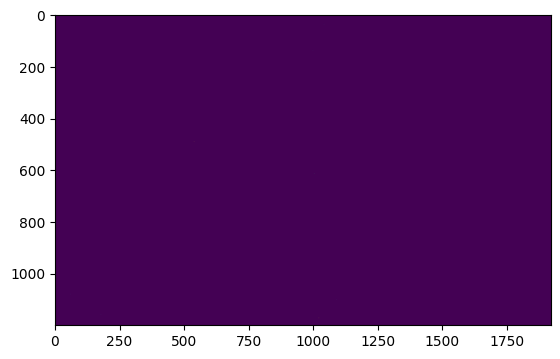

In [16]:
# Position after Homing 

try:
    client.positionersManager.homeAxis(positioner_name=None, axis="X", is_blocking=False)
except:
    print("Probably Timeout X")
try:
    client.positionersManager.homeAxis(positioner_name=None, axis="Y", is_blocking=False)
except:
    print("Probably TimeoutY")
try:
    client.positionersManager.homeAxis(positioner_name=None, axis="Z", is_blocking=False)
except:
    print("Probably Timeout Z")


In [18]:
positioner_name = client.positionersManager.allStageNames[0]
currentPositions = client.positionersManager.getPositionerPositions()[positioner_name]
initialPosition = (currentPositions["X"], currentPositions["Y"])
initialPosiionZ = currentPositions["Z"]
print(currentPositions)

{'A': 31900.0, 'X': 66570.80882352941, 'Y': -1293.2536764705874, 'Z': 54621.5625}


In [20]:
# utrn on laser/led
laser_names = client.lasersManager.getLaserNames()
print(laser_names)
mLaserName = laser_names[-1]
client.lasersManager.setLaserActive(mLaserName, True)
client.lasersManager.setLaserValue(mLaserName, 1023)

['405', '532', '488', '635', 'LED']


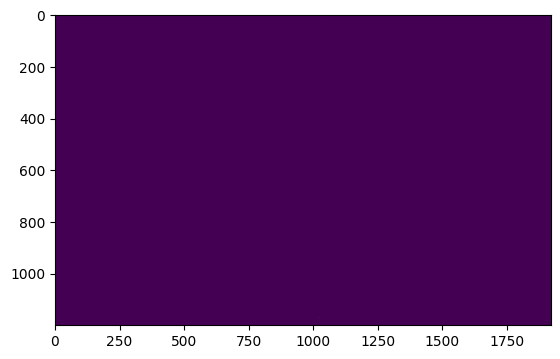

In [21]:

img = client.recordingManager.snapNumpyToFastAPI()

plt.imshow(img)
plt.show()



In [25]:
# move to certain position 

posX = 100000
posY = 20000
client.positionersManager.movePositioner(positioner_name, "X", posX, is_absolute=True, is_blocking=False, speed=20000)
client.positionersManager.movePositioner(positioner_name, "Y", posY, is_absolute=True, is_blocking=False, speed=20000)

import time
time.sleep(5)



TypeError: positionersManager.movePositioner() missing 1 required positional argument: 'dist'

In [28]:
# move back
client.positionersManager.movePositioner(positioner_name,  "X", currentPositions["X"], is_absolute=True, is_blocking=False, speed=20000)
client.positionersManager.movePositioner(positioner_name, "Y", currentPositions["Y"],  is_absolute=True, is_blocking=False, speed=20000)


In [29]:
client.positionersManager.movePositioner(positioner_name,  "Z", 50000, is_absolute=True, is_blocking=False, speed=20000)

time.sleep(1)
client.positionersManager.movePositioner(positioner_name,  "Z", currentPositions["Z"], is_absolute=True, is_blocking=False, speed=20000)
